In [61]:
import torch
import torchvision
torchvision.disable_beta_transforms_warning()
from torchvision import transforms
from functools import partial
from collections.abc import Callable
from generative.networks.nets import SPADEDiffusionModelUNet
from generative.utils import unsqueeze_right
from monai.utils import optional_import
tqdm, has_tqdm = optional_import("tqdm", name="tqdm")
from matplotlib import pyplot as plt
from PIL import Image
from diffusers import DDPMScheduler
from monai.inferers import DiffusionInferer
from monai_model import DDPMPL
import os
device = torch.device("cuda")


In [62]:
original_image_path = "/mnt/raid/home/ajarry/data/ultrasound.png"
original_image = Image.open(original_image_path).convert("RGB")
transform = transforms.Compose([
            transforms.Resize((256, 256)),
            transforms.ToTensor(),
 ])
original_image = transform(original_image)
original_image = original_image.unsqueeze(0).to(device)
print(original_image.size())
noise = torch.rand_like(original_image)

torch.Size([1, 3, 256, 256])


torch.Size([701])
torch.Size([])
torch.Size([1000])


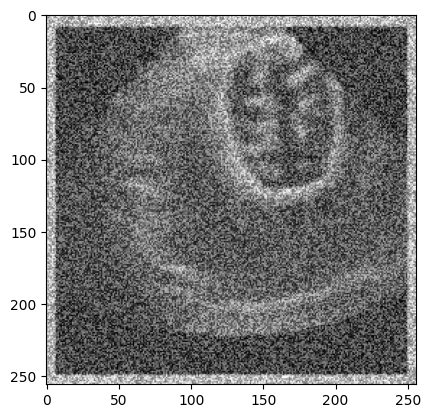

In [63]:
scheduler = DDPMScheduler(num_train_timesteps=1000, beta_schedule="linear")
start_timestep = 700
noise_start_step = scheduler.timesteps[start_timestep].long()
truncated_timesteps = scheduler.timesteps[scheduler.timesteps <= start_timestep].long()
print(truncated_timesteps.shape)
print(noise_start_step.shape)
print(scheduler.timesteps.shape)
image = scheduler.add_noise(original_image,noise,noise_start_step)
display_noisy_image = scheduler.add_noise(original_image,noise,noise_start_step).cpu().squeeze()
plt.imshow(display_noisy_image[0],cmap="gray")

In [64]:
inferer = DiffusionInferer(scheduler)
hparams = {
    'lr': 1e-4,
    'weight_decay': 1e-5,
    'num_train_timesteps': 1000,
    'in_channels': 3,
    'out_channels': 3,
    'use_pre_trained': False,
    'num_channels': (3, 256, 256),

}
model = DDPMPL(**hparams)
# Generate a sample
state_dict = torch.load("/mnt/raid/home/ajarry/data/outputs_monai/output_20250218_124542/model.pth")
model.load_state_dict(state_dict, strict=False)
model = model.to(device)
print(original_image.shape)
progress_bar = tqdm(truncated_timesteps)
conditioning = original_image
for t in progress_bar:
    model_output = model(image, timesteps=t)
    image, _ = scheduler.step(model_output, t, image,return_dict=False)

torch.Size([1, 3, 256, 256])


  2%|▏         | 14/701 [12:26<10:10:11, 53.29s/it]


KeyboardInterrupt: 

: 

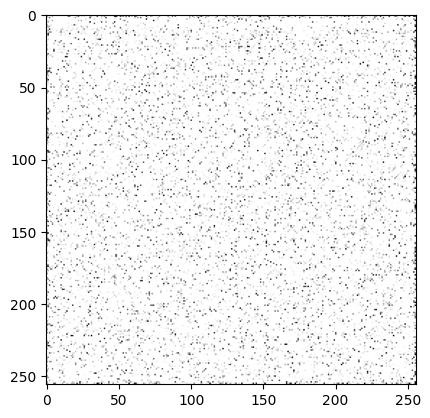

In [43]:
img = model_output.squeeze().cpu()
plt.imshow(img[0],cmap="gray")